In [2]:
import numpy as np
import pandas as pd
monthly = pd.read_csv("C:\PYTHON\monthly_deaths.csv")
yearly = pd.read_csv("C:\PYTHON\yearly_deaths_by_clinic.csv")




In [3]:
monthly

,date,births,deaths
0,1841-01-01,254,37
1,1841-02-01,239,18
2,1841-03-01,277,12
3,1841-04-01,255,4
4,1841-05-01,255,2
...,...,...,...
93,1848-11-01,310,9
94,1848-12-01,373,5
95,1849-01-01,403,9
96,1849-02-01,389,12


In [4]:
yearly

,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1
3,1844,3157,260,clinic 1
4,1845,3492,241,clinic 1
5,1846,4010,459,clinic 1
6,1841,2442,86,clinic 2
7,1842,2659,202,clinic 2
8,1843,2739,164,clinic 2
9,1844,2956,68,clinic 2


In [7]:
monthly.isna().sum()

date      0
births    0
deaths    0
dtype: int64

In [8]:
yearly.isna().sum()

year      0
births    0
deaths    0
clinic    0
dtype: int64

In [9]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    98 non-null     object
 1   births  98 non-null     int64 
 2   deaths  98 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 2.4+ KB


In [10]:
import matplotlib.pyplot as plt

In [13]:
# We See Clinic wise deaths
yearly.groupby("clinic").sum()["deaths"]

clinic
clinic 1    1989
clinic 2     691
Name: deaths, dtype: int64

In [15]:
# To make the analysis easier, we can calculate the proportion of deaths.
yearly["Proportion_of_deaths"] = yearly["deaths"]/yearly["births"]
yearly

,year,births,deaths,clinic,Proportion_of_deaths
0,1841,3036,237,clinic 1,0.078063
1,1842,3287,518,clinic 1,0.157591
2,1843,3060,274,clinic 1,0.089542
3,1844,3157,260,clinic 1,0.082357
4,1845,3492,241,clinic 1,0.069015
5,1846,4010,459,clinic 1,0.114464
6,1841,2442,86,clinic 2,0.035217
7,1842,2659,202,clinic 2,0.075968
8,1843,2739,164,clinic 2,0.059876
9,1844,2956,68,clinic 2,0.023004


In [16]:
 # Now we check  that which year has heigher Proportion of deaths
yearly.groupby("year").sum("Proportion_of_deaths")

,births,deaths,Proportion_of_deaths
year,,,
1841,5478,323,0.113280
1842,5946,720,0.233559
1843,5799,438,0.149418
1844,6113,328,0.105361
1845,6733,307,0.089379
1846,7764,564,0.142434


In [18]:
# Separate the dataset into 2 datasets, one for each clinic

clinic1 = yearly[yearly["clinic"]=="clinic 1"]
clinic2 = yearly[yearly["clinic"]=="clinic 2"]

In [19]:
clinic1

,year,births,deaths,clinic,Proportion_of_deaths
0,1841,3036,237,clinic 1,0.078063
1,1842,3287,518,clinic 1,0.157591
2,1843,3060,274,clinic 1,0.089542
3,1844,3157,260,clinic 1,0.082357
4,1845,3492,241,clinic 1,0.069015
5,1846,4010,459,clinic 1,0.114464


In [20]:
clinic2

,year,births,deaths,clinic,Proportion_of_deaths
6,1841,2442,86,clinic 2,0.035217
7,1842,2659,202,clinic 2,0.075968
8,1843,2739,164,clinic 2,0.059876
9,1844,2956,68,clinic 2,0.023004
10,1845,3241,66,clinic 2,0.020364
11,1846,3754,105,clinic 2,0.027970


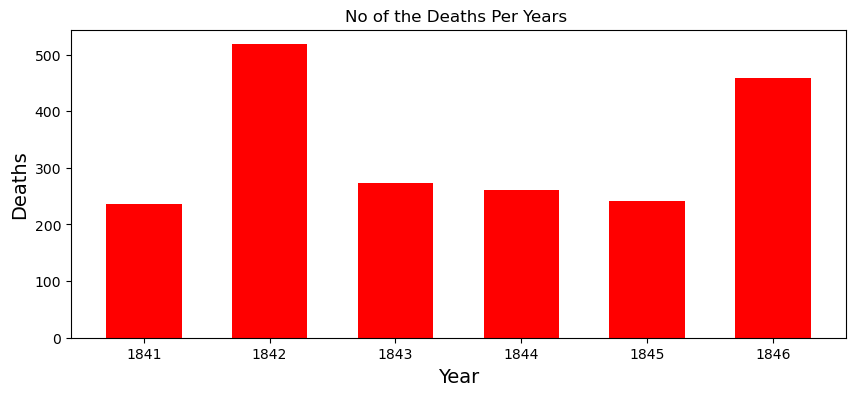

In [21]:
# Visualize the Number of deaths every year in both Clinic 
fig,ax = plt.subplots(figsize = (10,4))
plt.bar(yearly.year,yearly.deaths,width=0.6,color="red")
plt.title("No of the Deaths Per Years ")
plt.xlabel("Year",fontsize = 14)
plt.ylabel("Deaths",fontsize = 14)
plt.show()

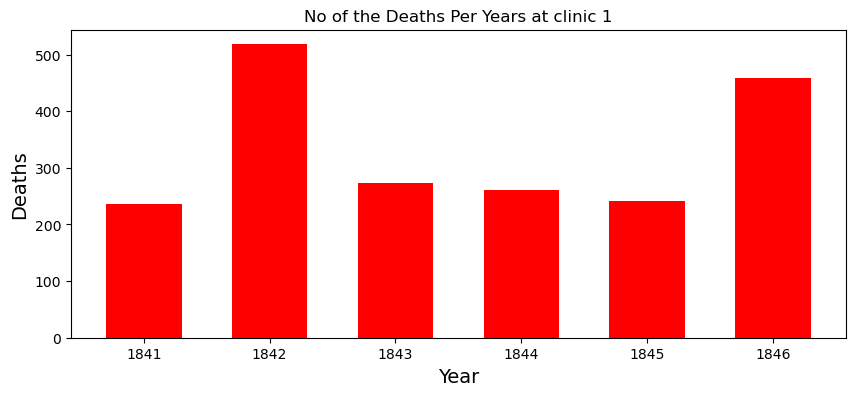

In [22]:
#Visualize the Number of deaths every year in by Clinic 1
fig,ax = plt.subplots(figsize = (10,4))
plt.bar(clinic1.year,clinic1.deaths,width=0.6,color="red")
plt.title("No of the Deaths Per Years at clinic 1")
plt.xlabel("Year",fontsize = 14)
plt.ylabel("Deaths",fontsize = 14)
plt.show()

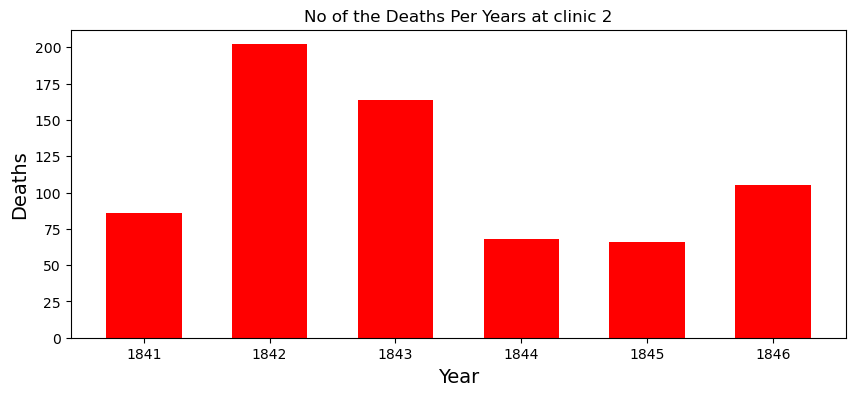

In [24]:
#Visualize the Number of deaths every year in by Clinic 2
fig,ax = plt.subplots(figsize = (10,4))
plt.bar(clinic2.year,clinic2.deaths,width=0.6,color="red")
plt.title("No of the Deaths Per Years at clinic 2")
plt.xlabel("Year",fontsize = 14)
plt.ylabel("Deaths",fontsize = 14)
plt.show()

In [2]:
ax= clinic1.plot(x= "year", y= "Proportion_of_deaths", label= "clinic1", color="red")
clinic2.plot(x= "year", y= "Proportion_of_deaths", label= "clinic2", ax=ax, ylabel= "Proportion_of_deaths", color="green")

NameError: name 'clinic1' is not defined

In [36]:
monthly.head()

,date,births,deaths
0,1841-01-01,254,37
1,1841-02-01,239,18
2,1841-03-01,277,12
3,1841-04-01,255,4
4,1841-05-01,255,2


In [37]:
## Date is in Object Formate we change it into Date Formte
monthly["date"] = pd.to_datetime(monthly["date"])
monthly.dtypes

date      datetime64[ns]
births             int64
deaths             int64
dtype: object

In [42]:
monthly["Proportion_of_death"] = round(monthly["deaths"]/monthly["births"],2)*100

monthly


,date,births,deaths,Proportion_of_death
0,1841-01-01,254,37,15.0
1,1841-02-01,239,18,8.0
2,1841-03-01,277,12,4.0
3,1841-04-01,255,4,2.0
4,1841-05-01,255,2,1.0
...,...,...,...,...
93,1848-11-01,310,9,3.0
94,1848-12-01,373,5,1.0
95,1849-01-01,403,9,2.0
96,1849-02-01,389,12,3.0


In [ ]:
# “In 1847, Dr. Semmelweis made handwashing compulsory for doctors to reduce deaths, and with monthly data, we can compare death rates before and after this change.”

In [44]:
started_date = pd.to_datetime("1847-06-01")

before_handwashing = monthly[monthly["date"] < started_date]
after_handwashing = monthly[monthly["date"] >= started_date]

In [45]:
before_handwashing

,date,births,deaths,Proportion_of_death
0,1841-01-01,254,37,15.0
1,1841-02-01,239,18,8.0
2,1841-03-01,277,12,4.0
3,1841-04-01,255,4,2.0
4,1841-05-01,255,2,1.0
...,...,...,...,...
71,1847-01-01,311,10,3.0
72,1847-02-01,312,6,2.0
73,1847-03-01,305,11,4.0
74,1847-04-01,312,57,18.0


In [46]:
after_handwashing

,date,births,deaths,Proportion_of_death
76,1847-06-01,268,6,2.0
77,1847-07-01,250,3,1.0
78,1847-08-01,264,5,2.0
79,1847-09-01,262,12,5.0
80,1847-10-01,278,11,4.0
81,1847-11-01,246,11,4.0
82,1847-12-01,273,8,3.0
83,1848-01-01,283,10,4.0
84,1848-02-01,291,2,1.0
85,1848-03-01,276,0,0.0


Text(0, 0.5, 'Proportion of Deaths')

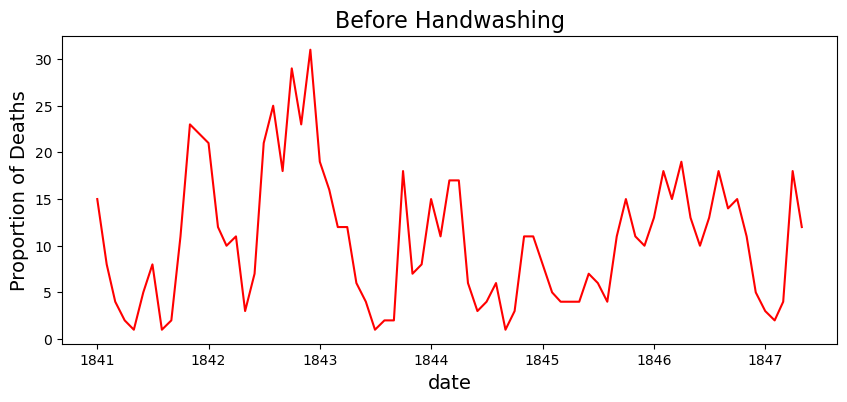

In [49]:
fig,ax = plt.subplots(figsize = (10,4))
x= before_handwashing["date"]
y= before_handwashing["Proportion_of_death"]
plt.plot(x, y, color= "red")
plt.title("Before Handwashing", fontsize=16)
plt.xlabel("date", fontsize=14)
plt.ylabel("Proportion of Deaths", fontsize=14)

Text(0, 0.5, 'Proportion of Deaths')

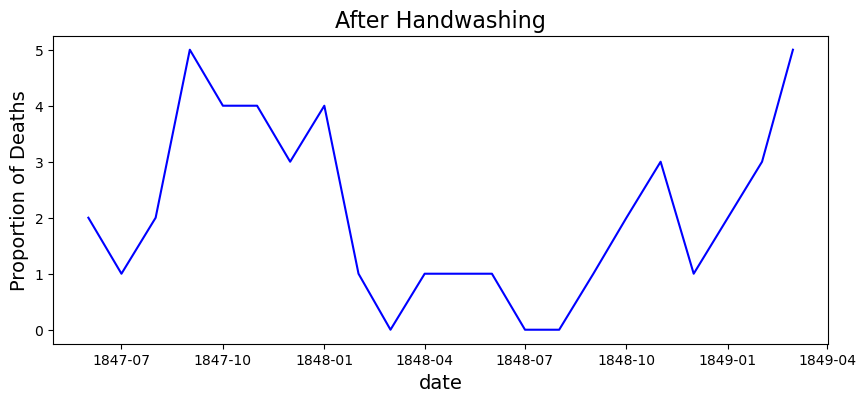

In [52]:
fig,ax = plt.subplots(figsize = (10,4))
x= after_handwashing["date"]
y= after_handwashing["Proportion_of_death"]
plt.plot(x, y, color= "blue")
plt.title("After Handwashing", fontsize=16)
plt.xlabel("date", fontsize=14)
plt.ylabel("Proportion of Deaths", fontsize=14)

<Axes: xlabel='date'>

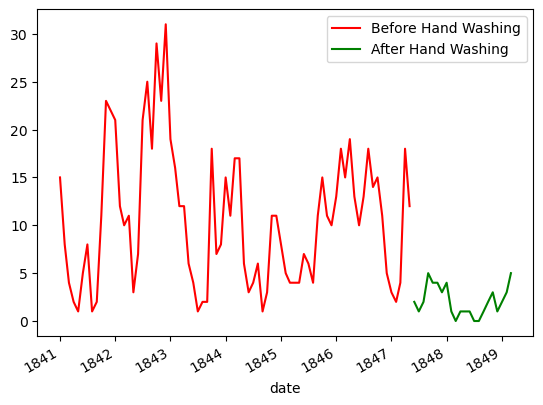

In [54]:
ax = before_handwashing.plot(x = "date",y="Proportion_of_death",label = "Before Hand Washing",color = "red")
after_handwashing.plot(x = "date",y = "Proportion_of_death",label = "After Hand Washing",ax=ax,color = "green")

In [55]:
before_proportion = before_handwashing["Proportion_of_death"]
after_proportion = after_handwashing["Proportion_of_death"]
print(before_proportion.mean())

10.460526315789474


In [56]:
print(after_proportion.mean())

2.090909090909091


In [58]:
mean_diff = after_proportion.mean() - before_proportion.mean()
print(mean_diff)

-8.369617224880383


In [ ]:
##The Negative sign shows a decrease,meaning deaths fell from 10 to 2 % after handwashing,a drop of about 8%